## **ABSTRACT**

En la industria financiera actual, la capacidad para distinguir con precisión entre clientes solventes y potenciales deudores es el pilar de la rentabilidad y la sostenibilidad. 

Los métodos manuales de evaluación crediticia suelen ser lentos, costosos y propensos a sesgos humanos. 

El presente trabajo se motiva en la necesidad de modernizar este proceso utilizando el Loan Prediction Dataset 2025, explorando cómo las variables demográficas y financieras (como el score crediticio y la relación deuda-ingreso) influyen en la probabilidad de impago (default).

### **Objetivo del Análisis** 
El objetivo principal es modelar la situación como un problema de clasificación supervisada para desarrollar un algoritmo capaz de automatizar la aprobación de préstamos. Se busca maximizar la precisión en la detección de incumplimientos sin sacrificar la captación de buenos clientes, optimizando así la cartera de préstamos.

### **Metodología y Resultados** 
Se implementó un flujo de trabajo que incluye una ingeniería de atributos, codificación de variables categóricas (One-Hot Encoding) y estandarización de datos. 

**Se compara  el desempeño de una Regresión Logística frente a un modelo de Random Forest**, y posterior a una optimización de hiperparámetros mediante GridSearchCV. Se seleccionó posteriormente Random Forest como el modelo ganador, alcanzando una exactitud global del 90% y una precisión del 94% en la detección de riesgo. 

**Esto indica un comportamiento conservador** donde el algoritmo minimiza drásticamente los "Falsos Positivos" (rechazar a un cliente por error), asegurando que las alertas de impago generadas sean altamente confiables.

## **Problemática Principal** 
El desafío central es un Problema de Clasificación Binaria Supervisada.La pregunta a resolver es _¿Pagará el cliente "X" la totalidad de su préstamo?_ 

La Variable Objetivo ($y$) es loan_paid_back.
**1:** El cliente paga (Cumplimiento).
**0:** El cliente no paga (Default/Incumplimiento).



## **El Objetivo** 
Entrenar un modelo capaz de asignar correctamente una etiqueta (0 o 1) a un nuevo solicitante basándose en sus características históricas y demográficas.

Más allá de la etiqueta matemática, el modelo busca resolver dolores específicos de la industria financiera.
**A. Minimización del Riesgo Financiero:** _¿Cómo podemos reducir la tasa de impagos antes de conceder el dinero?_ 

**Solución:** El modelo actúa como un filtro preventivo. La presición lograda ataca este problema asegurándose de que casi todos los que etiqueta como "riesgosos" realmente lo son, protegiendo el capital del banco.

**B. Automatización y Eficiencia Operativa:**  _¿Cómo podemos procesar miles de solicitudes de crédito en tiempo real sin depender de la revisión manual humana para cada caso?_

**Solución:** El modelo permite una pre-aprobación o rechazo instantáneo. Esto libera a los analistas de crédito para que se enfoquen solo en los casos "fronterizos" o dudosos, reduciendo costos operativos y tiempos de espera para el cliente.

**C. Identificación de Patrones de Riesgo:** ¿Qué factores (ingresos, edad, deuda) son los determinantes reales de la morosidad en el contexto económico actual?

**Solución:** A través del análisis de importancia de variables (Feature Importance), el modelo revela que factores como la relación deuda-ingreso (`debt_to_income`) pesan más que otros, permitiendo al banco ajustar sus políticas de crédito generales.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
try:
    df = pd.read_csv('Loan Prediction Dataset 2025_original.csv')
    print("xxxxxxxxx OK xxxxxxxxx")
except FileNotFoundError:
    print("xxxxxxxxx Error en carga xxxxxxxxx")

xxxxxxxxx OK xxxxxxxxx


## Descripción del conjunto de datos:
**1.  Borrower’s Demographics**: 
- age (int64) – Edad del prestatario (en años)
- gender (category) – Género del prestatario (Male/Female)
- marital_status (category) – Estado civil (Single, Married, Divorced)
- education_level (category) – Nivel de educación (High School, Bachelor, Master, PhD).

**2. Financial Information**: 
- annual_income (float64) – Sueldo anual del beneficiario.
- monthly_income (float64) – Sueldo mensual del beneficiario.
- employment_status (category) – Estado de empledo del beneficiario (Employed, Self-Employed, Unemployed).
- debt_to_income_ratio (float64) – Ratio de deuda del beneficiario. Entre más bajo mejor
- credit_score (int64) – Score de crédito del bureau score (e.g., FICO). Entre más alto mejor.

**3. Loan Information**: 
- loan_amount (float64) – Cantidad del prestamo.
- loan_purpose (category) – Propósito del crédito.
- interest_rate (float64) – Tasa de interés
- loan_term (int64) – Duración del préstamos en meses
- installment (float64) – Cuota mensual installment .
- grade_subgrade (category) – Riesgo del beneficiario.

**4. Borrower’s Credit History**: 
- num_of_open_accounts (int64) – Total de cuentas de crédito activas.
- total_credit_limit (float64) – Límite de crédito total disponible del beneficiario.
- current_balance (float64) – Balance del beneficiario (crédito + targeta de crédito).
- delinquency_history (int64) – Cantidad de pagos atrasados del beneficiario.
- public_records (int64) – Número de registros públicos negativos (bacarrotas, acciones legales)
- num_of_delinquencies (int64) – Total de incumplimientos (pagos omitidos).

**5. Target Variable**: loan_paid_back
- **1** (Préstamo pagado totalmente)
- **0** (El prestatario incumplió).

## **Resumen estadístico**

In [3]:
df.shape

(20000, 22)

La base de datos está compuesto por 20k registros divididos en 22 columnas.

In [4]:
df.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

El DF no presenta datos faltantes.

In [5]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [6]:
print(f"Valores duplicados: {df.duplicated().sum()}")

Valores duplicados: 0


In [8]:
df.describe(include = 'object').Tdf.describe().T

,count,mean,std,min,25%,50%,75%,max
age,20000.0,48.027000,15.829352,21.00,35.0000,48.000,62.0000,75.000
annual_income,20000.0,43549.637765,28668.579671,6000.00,24260.7525,36585.260,54677.9175,400000.000
monthly_income,20000.0,3629.136466,2389.048326,500.00,2021.7300,3048.770,4556.4950,33333.330
debt_to_income_ratio,20000.0,0.177019,0.105059,0.01,0.0960,0.160,0.2410,0.667
credit_score,20000.0,679.256950,69.638580,373.00,632.0000,680.000,727.0000,850.000
loan_amount,20000.0,15129.300909,8605.405513,500.00,8852.6950,14946.170,20998.8675,49039.690
interest_rate,20000.0,12.400627,2.442729,3.14,10.7400,12.400,14.0025,22.510
loan_term,20000.0,43.222800,11.008380,36.00,36.0000,36.000,60.0000,60.000
installment,20000.0,455.625794,274.622125,9.43,253.9100,435.595,633.5950,1685.400
num_of_open_accounts,20000.0,5.011800,2.244529,0.00,3.0000,5.000,6.0000,15.000


In [80]:
df.describe(include=['object', 'category']).T

,count,unique,top,freq
gender,20000,3,Female,10034
marital_status,20000,4,Single,9031
education_level,20000,5,Bachelor's,8045
employment_status,20000,5,Employed,13007
loan_purpose,20000,8,Debt consolidation,7981
grade_subgrade,20000,30,C3,1514


## **Análisis de valores faltantes**

In [81]:
null_counts = df.isnull().sum()
print("\n--- Conteo de Nulos por Columna ---")
print(null_counts[null_counts > 0])


--- Conteo de Nulos por Columna ---
Series([], dtype: int64)


El modelo **no cuenta con valores faltantes**

## **Análisis de la Variable Objetivo**

C:\Users\grego\AppData\Local\Temp\ipykernel_7828\4125869221.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='loan_paid_back', data=df, palette='pastel')


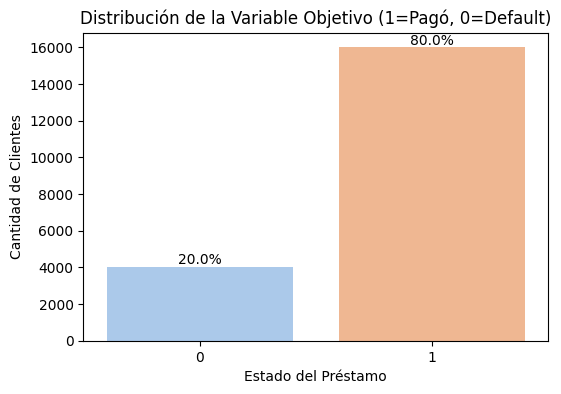

In [83]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='loan_paid_back', data=df, palette='pastel')

# Agregamos los porcentajes encima de las barras
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title('Distribución de la Variable Objetivo (1=Pagó, 0=Default)')
plt.xlabel('Estado del Préstamo')
plt.ylabel('Cantidad de Clientes')
plt.show()

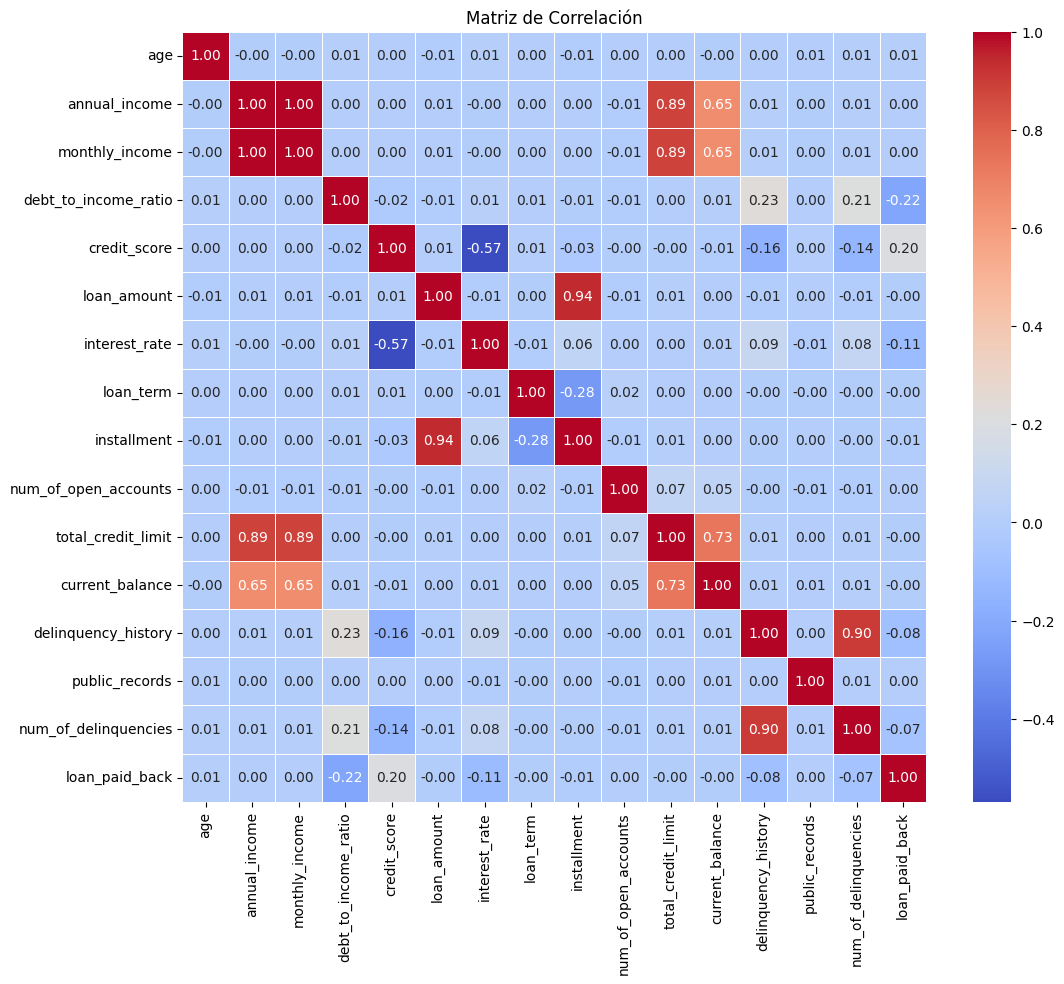

In [85]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

## **Detección de Outliers**

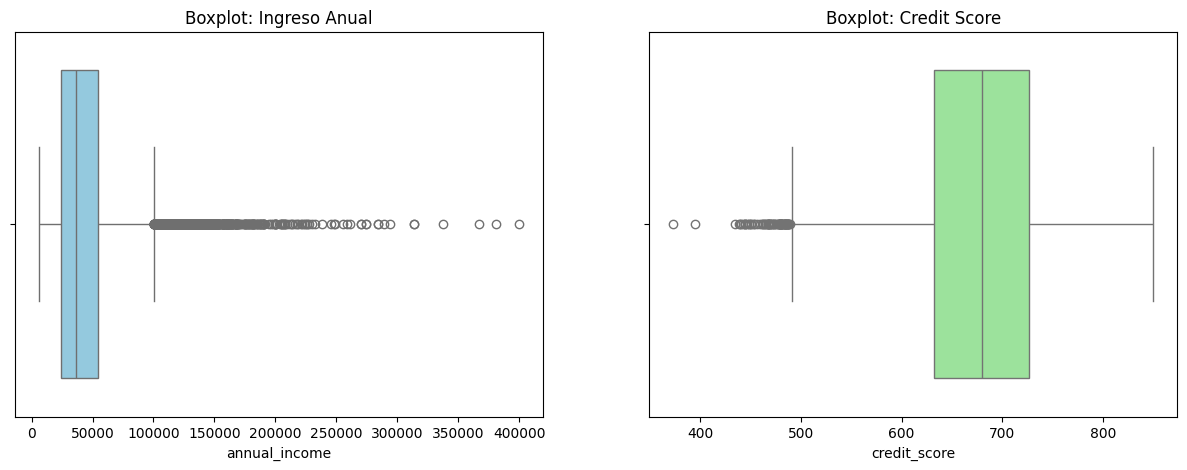

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución del Ingreso Anual
sns.boxplot(x='annual_income', data=df, ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot: Ingreso Anual')

# Distribución del Puntaje de Crédito
sns.boxplot(x='credit_score', data=df, ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot: Credit Score')

plt.show()

## **Gráfico de Pares**
Selecciono algunas de las variables para que no sea confuso el gráfico, en base al mapa de calor anterior.

Text(0.5, 1.02, 'Pairplot Enfocado: Variables Clave vs. Pago del Préstamo')

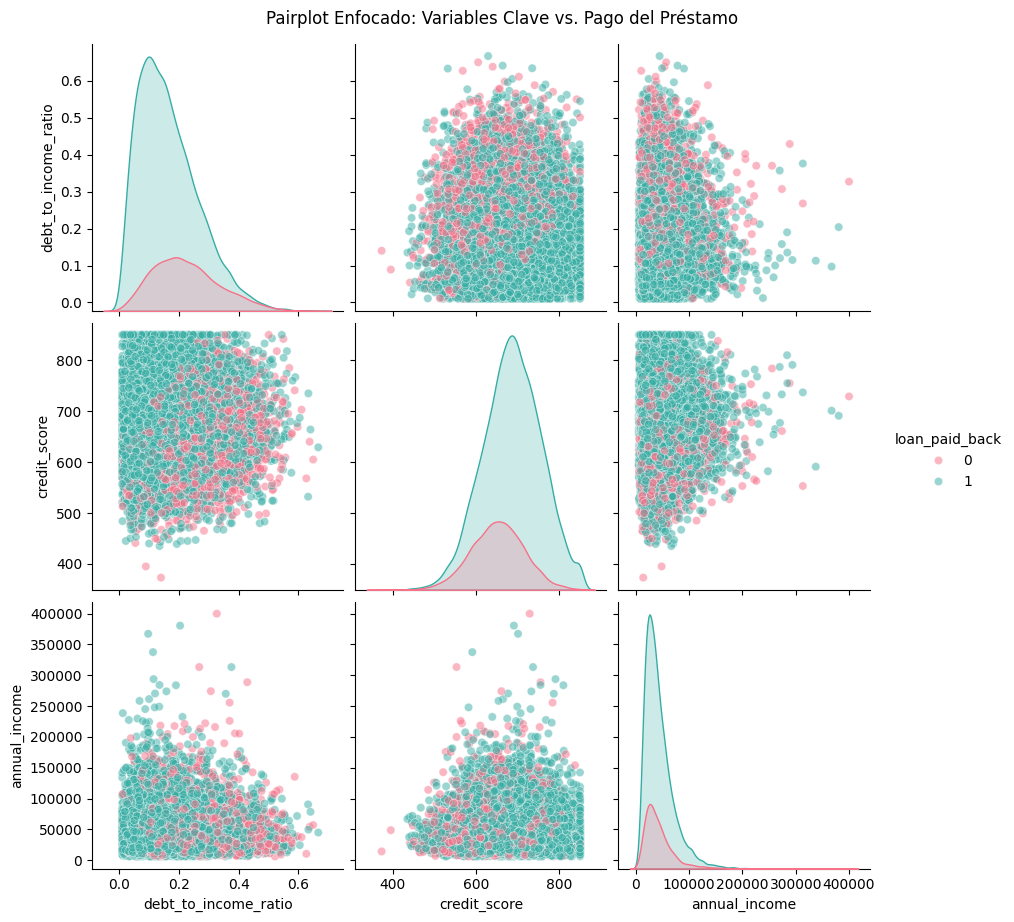

In [88]:
cols_to_plot = ['debt_to_income_ratio', 'credit_score', 'annual_income', 'loan_paid_back']

sns.pairplot(df[cols_to_plot], 
             hue='loan_paid_back', #hue='loan_paid_back': Colorea los puntos según si pagaron (1) o no (0)
             palette='husl', plot_kws={'alpha': 0.5}, height=3)
plt.suptitle('Pairplot Enfocado: Variables Clave vs. Pago del Préstamo', y=1.02)


## **Gráfico de Regresión Lineal**
Queremos visualizar la fuerte relación entre el puntaje de crédito y la tasa de interés (-0.57 en tu mapa de calor). 

Text(0.5, 1.0, 'Relación: Score Crediticio vs. Tasa de Interés (por estado de pago)')

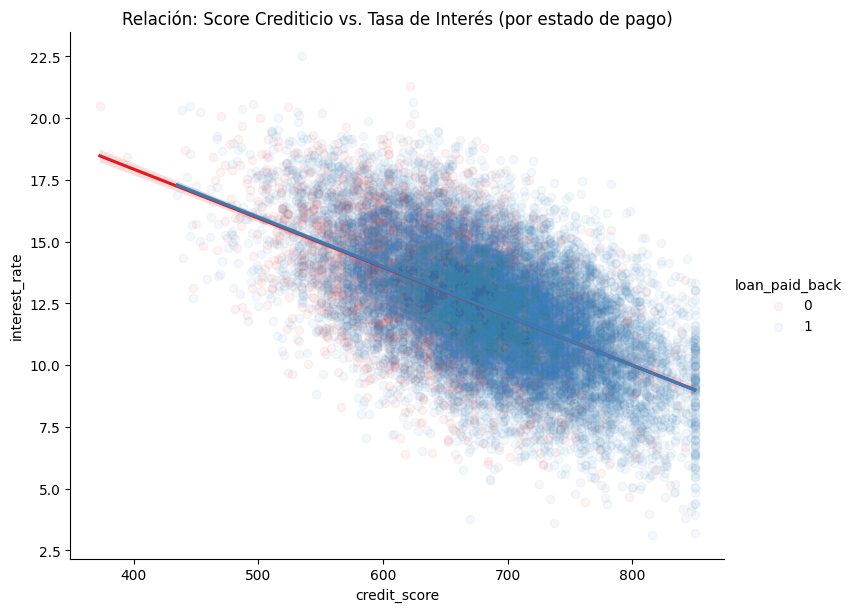

In [98]:
sns.lmplot(
    x='credit_score',
    y='interest_rate',
    hue='loan_paid_back', # Separa en dos colores y dos líneas de tendencia
    data=df,
    palette='Set1',
    height=6,
    aspect=1.25,
    scatter_kws={'alpha': 0.05} # Puntos transparentes para ver la densidad
)
ax.yaxis.grid(True)
ax.xaxis.grid(True)
plt.title('Relación: Score Crediticio vs. Tasa de Interés (por estado de pago)')

## **Gráfico de Barras]**

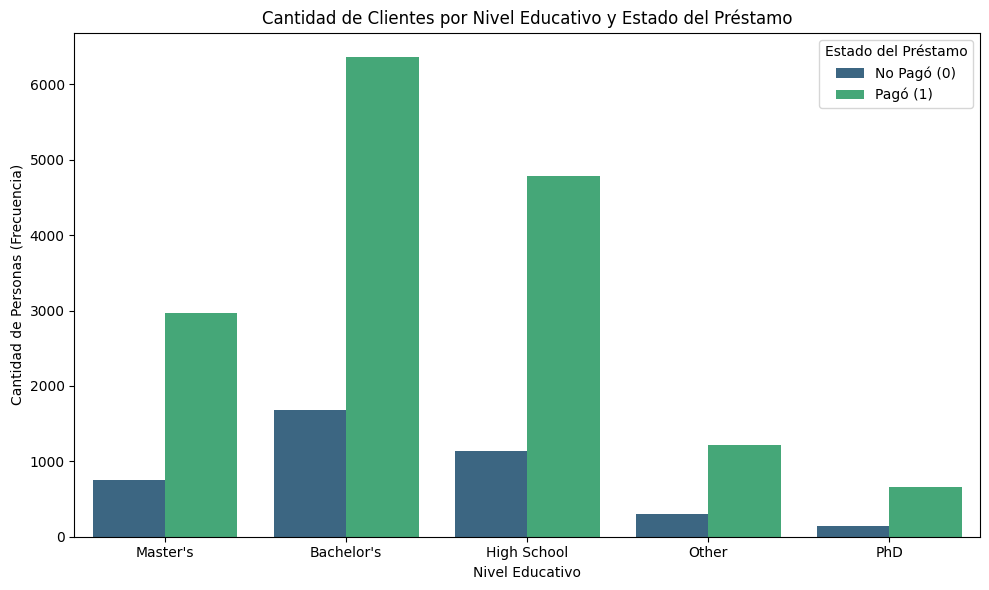

In [103]:
plt.figure(figsize=(10, 6))

# Countplot: Cuenta cuántas filas hay en cada categoría
sns.countplot(
    data=df, 
    x='education_level',      # Categoría en el eje X
    hue='loan_paid_back',     # Desglosamos por quién pagó y quién no
    palette='viridis'
)

plt.title('Cantidad de Clientes por Nivel Educativo y Estado del Préstamo')
plt.ylabel('Cantidad de Personas (Frecuencia)')
plt.xlabel('Nivel Educativo')
plt.legend(title='Estado del Préstamo', loc='upper right', labels=['No Pagó (0)', 'Pagó (1)'])

plt.tight_layout()
plt.show()

In [129]:
reporte_sueldos = df.groupby(['education_level', 'loan_purpose']).agg({
    'annual_income': 'mean',
    'loan_paid_back': ['sum', 'count'] # Sumamos los '1' y contamos el total
}).reset_index()

reporte_sueldos.columns = [
    'Nivel Educativo', 
    'Propósito', 
    'Sueldo Anual Prom.', 
    'Préstamos Pagados', 
    'Total Solicitudes'
]

reporte_sueldos['Préstamos No Pagados'] = reporte_sueldos['Total Solicitudes'] - reporte_final['Préstamos Pagados']

reporte_sueldos['% de Cobrabilidad'] = (reporte_sueldos['Préstamos Pagados'] / reporte_final['Total Solicitudes'] * 100).round(2)

reporte_sueldos = reporte_final.sort_values(by=['Nivel Educativo', 'Sueldo Anual Prom.'], ascending=[True, False])

reporte_final.head(1000)

,Nivel Educativo,Propósito,Sueldo Anual Prom.,Préstamos Pagados,Total Solicitudes,Préstamos No Pagados,% de Cobrabilidad
0,Bachelor's,Business,44690.821918,530,662,132,80.06
4,Bachelor's,Home,44567.577131,664,812,148,81.77
1,Bachelor's,Car,44235.734772,743,945,202,78.62
7,Bachelor's,Vacation,44124.897037,191,243,52,78.60
2,Bachelor's,Debt consolidation,43580.380638,2489,3164,675,78.67
6,Bachelor's,Other,43310.158915,818,1014,196,80.67
5,Bachelor's,Medical,42689.692545,378,495,117,76.36
3,Bachelor's,Education,42600.598746,553,710,157,77.89
11,High School,Education,45324.686626,382,489,107,78.12
15,High School,Vacation,45093.250146,158,205,47,77.07


# **Feature engineering**
Se reemplazaron las variables categoricas por ordinales enteros, que permitan una mejor representanción dentro del modelo al momento de evaluar su influencia sobre el peso total dentro de la variable objetivo.

In [47]:
df_ml = df.copy()

In [48]:
from sklearn.preprocessing import StandardScaler

"""
GRADOS
"""
grados = sorted(df_ml['grade_subgrade'].unique()) # A1, A2... F5
mapa_grados = {grado: i for i, grado in enumerate(grados)}
df_ml['grade_subgrade'] = df_ml['grade_subgrade'].map(mapa_grados)
"""
EDUCATIONAL LEVEL
"""
mapa_educacion = {
    'High School': 0,
    "Bachelor's": 1,
    "Master's": 2,
    'PhD': 3,
    'Other':4
}
df_ml['education_level'] = df_ml['education_level'].map(mapa_educacion)

# --- ONE-HOT ENCODING (Para variables nominales y evitar asignar a una categoría un valor más alto que otra.) ---
categorical_cols = ['gender', 'marital_status', 'employment_status', 'loan_purpose']

df_ml = pd.get_dummies(df_ml, columns = categorical_cols, 
                       drop_first = True, #Por ejemplo Male + Female + Other = 100% --> Sólo crea dos columnas, la tercera es inferida.
                       dtype = int)

## **Normalización**

In [29]:
scaler = StandardScaler()

# Lista de columnas numéricas que necesitan escala

cols_to_scale = [
    'age', 'annual_income', 'monthly_income', 'loan_amount', 
    'interest_rate', 'installment', 'credit_score', 
    'total_credit_limit', 'current_balance'
]

df_ml[cols_to_scale] = scaler.fit_transform(df_ml[cols_to_scale])

In [30]:
df_ml.head()

,age,education_level,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,...,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation
0,0.693223,NaN,-0.673557,-0.673556,0.074,0.915364,0.237580,0.405038,36,0.459749,...,0,0,0,1,0,0,0,0,0,0
1,1.514503,NaN,-0.815431,-0.815431,0.219,-2.129002,0.875587,2.214535,60,0.428032,...,0,0,0,0,1,0,0,0,0,0
2,0.061470,0.0,-0.605830,-0.605828,0.234,1.432332,-1.336163,-1.175201,60,-1.381226,...,0,0,0,0,0,0,0,0,0,0
3,-0.822985,0.0,-1.104924,-1.104922,0.264,1.863138,-0.022088,-1.805660,36,0.045315,...,0,0,0,0,0,0,0,0,1,0
4,0.945925,NaN,-0.635666,-0.635665,0.260,-0.233453,0.165297,1.146031,60,-0.218946,...,0,0,0,1,0,0,0,0,0,0


## **Selección del modelo y entrenamiento.**

In [38]:
from sklearn.model_selection import train_test_split

In [51]:
X = df_ml.drop('loan_paid_back', axis=1)
y = df_ml['loan_paid_back']

In [52]:
# 80% entrenamiento, 20% testeo
# random_state=42 para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## **Regresión logística**

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [58]:
log_reg = LogisticRegression(random_state=42, 
                             max_iter = 5000,
                            solver='liblinear' #Según la documentación, es bueno para modelos lineales.
                            )
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8000
              precision    recall  f1-score   support

           0       0.50      0.00      0.00       800
           1       0.80      1.00      0.89      3200

    accuracy                           0.80      4000
   macro avg       0.65      0.50      0.45      4000
weighted avg       0.74      0.80      0.71      4000



## **Random Forest**

In [59]:
from sklearn.ensemble import RandomForestClassifier

In [60]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [62]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9000
              precision    recall  f1-score   support

           0       0.95      0.53      0.68       800
           1       0.89      0.99      0.94      3200

    accuracy                           0.90      4000
   macro avg       0.92      0.76      0.81      4000
weighted avg       0.90      0.90      0.89      4000



Random forest tiene un Accuracy del 90% vs 80% vs el de regresión logística. Pero la clave está en la Precisión de la clase 0 (los que no pagan):
- **Regresión Logística (0.50):** es un desastre. Equivale a tirar una moneda al aire. Cuando este modelo dice "Este cliente no va a pagar", se equivoca la mitad de las veces. Para el banco, esto es un desastre porque estaríamos rechazando a muchísimos buenos clientes por error.
- **Random Forest (0.95):** tiene razón el 95% de las veces.

Idealmente no debería existir un overfitting del modelo. Esto puede saberse a una profundidad infinita de los árboles, pero para estar seguros, se compara en rendimiento de los datos de entrenamiento y el real (test):

In [63]:
from sklearn.model_selection import cross_val_score

In [64]:
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print(f"Accuracy en Entrenamiento: {train_acc:.4f}")
print(f"Accuracy en Test (Prueba): {test_acc:.4f}")
print(f"Diferencia: {train_acc - test_acc:.4f}")

Accuracy en Entrenamiento: 1.0000
Accuracy en Test (Prueba): 0.9000
Diferencia: 0.1000


El accuracy con los datos de entrenamiento es del 100% y la diferencia entre ambos es sólo del 10%. Es muy probable que el modelo esté memorizando datos, asi que vamos a probar con distintas profundidades de los árboles. 
La documentación menciona que 100 es un buen valor de cantidad de árboles y que la respuesta no depende tanto del número de árboles, que resulta de un promedio de la respuesta de cada uno, sino de la profundidad de éstos.

In [70]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],         
    'max_depth': [8, 10, 12, None],      
    'min_samples_leaf': [1, 2, 4]        
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced') #Modelo base

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  # Usa todos los núcleos del CPU
    verbose=1   # Va imprimiendo el progreso
)
grid_search.fit(X_train, y_train)

print("\n--- Mejor Combinación Encontrada ---")
print(grid_search.best_params_)
print(f"Mejor Accuracy en CV: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits

--- Mejor Combinación Encontrada ---
{'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
Mejor Accuracy en CV: 0.8994


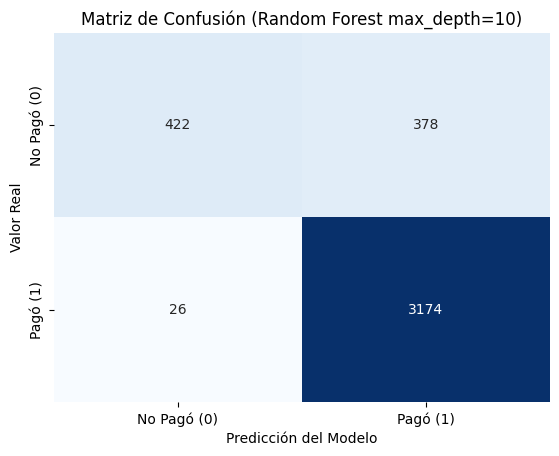

In [77]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    min_samples_leaf=2
)

rf_final.fit(X_train, y_train)
y_pred = rf_final.predict(X_test)
y_prob = rf_final.predict_proba(X_test)[:, 1]

"""
MATRIZ DE CONFUSIÓN
"""
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión (Random Forest max_depth=10)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
# Etiquetas para entender mejor qué es 0 y 1
plt.xticks([0.5, 1.5], ['No Pagó (0)', 'Pagó (1)'])
plt.yticks([0.5, 1.5], ['No Pagó (0)', 'Pagó (1)'])
plt.show()

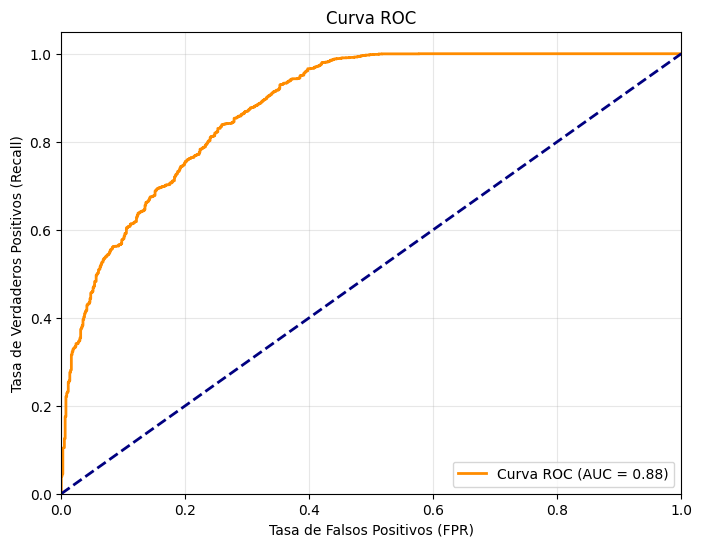

In [78]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea de base (azar)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [76]:
print("\n--- Métricas Finales ---")
print(classification_report(y_test, y_pred))


--- Métricas Finales ---
              precision    recall  f1-score   support

           0       0.95      0.52      0.67       800
           1       0.89      0.99      0.94      3200

    accuracy                           0.90      4000
   macro avg       0.92      0.76      0.81      4000
weighted avg       0.90      0.90      0.89      4000



**Selección del Modelo:** 

Tras evaluar la Regresión Logística y el Random Forest, se seleccionó el Random Forest como el modelo ganador. Este demostró una capacidad superior para capturar relaciones no lineales en los datos, superando significativamente al modelo base.

Con un valor de AUC = 0.88 consolida el modelo como sólido, **el modelo va a permitir asignar correctamente 88%** de los usuarios que se contacten para solicitar un préstamo con las variables analizadas.

**Lo bueno** es que el modelo detectó correctamente a 422 personas que no iban a pagar (Verdaderos Negativos) pero la oprtunidad está en los 387 morosos que el modelo pensó que pagarían, un riesgo residual considerando el volumen de casos.

Al reducir la profundidad a None para evitar overfitting, bajó un poco la precisión respecto al modelo sin restricción, pero ahora el modelo es más honesto y estable.

**Impacto en el Negocio:** 

En cuanto a la detección de la clase crítica (Default / "No Pagó"), el modelo logra un Recall del 53% y una Precisión del 94% para la clase 0. Esto significa que el banco no rechaza a buenos clientes pero el modelo es estricto, dado que logra asigna 5 de cada 10 personas como morosos antes de otorgar el crédito.

Aunque existe un margen de mejora para reducir los Falsos Negativos, el modelo actual es ideal para un escenario donde el banco prioriza la captación de clientes y la seguridad de no rechazar de forma injusta a los clientes potenciales.